# Week 06 · Day 3 — First ML Pipeline

## Baselines, Linear & Logistic Regression, and Metrics That Don't Lie

This notebook builds a complete, reproducible baseline-to-first-model ML pipeline using the same `students` dataset from Monday.

### Objectives
- Create model-ready features using one-hot encoding.
- Use the exact required train/test split for regression.
- Compare a mean regression baseline with Linear Regression using RMSE and R².
- Inspect Linear Regression coefficients.
- Create a binary `distinction` target (`exam_score >= 85`).
- Compare a majority-class classification baseline with Logistic Regression using accuracy, precision, recall, and F1.
- Keep the workflow reproducible with fixed random seeds.


## 1. Imports and Reproducibility

All randomness used to regenerate the dataset and split the data is explicitly seeded.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

RANDOM_SEED = 21
SPLIT_SEED = 42


## 2. Regenerate the Monday `students` Dataset

This follows the exact dataset specification from Monday: `seed=21`, `n=600`, sections A/B/C, study hours, sleep hours, attendance, and exam score.


In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (
    50
    + 2.6 * study_hours
    + 0.15 * attendance_pct
    + section_bonus
    + noise
).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

students.head()


,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


## 3. Data Quality Check

Before building the ML pipeline, we first check whether the dataset is clean and ready for modeling.

We will check:
- Dataset shape
- Data types
- Missing values
- Duplicate rows
- Basic descriptive statistics
- Unique values in categorical columns
- Valid ranges of numerical columns

This step helps us identify any data quality issues before feature engineering and model training.

In [3]:
# Dataset shape
print("Dataset shape:", students.shape)

# Data types
print("\nData types:")
print(students.dtypes)

# Missing values
print("\nMissing values:")
print(students.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", students.duplicated().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
display(students.describe())

# Unique values in categorical column
print("\nClass section values:")
print(students["class_section"].value_counts().sort_index())

# Validity checks
print("\nValidity checks:")

print(
    "Study hours below 0:",
    (students["study_hours_per_week"] < 0).sum()
)

print(
    "Sleep hours outside 3–10:",
    (
        (students["sleep_hours_per_night"] < 3)
        | (students["sleep_hours_per_night"] > 10)
    ).sum()
)

print(
    "Attendance outside 40–100:",
    (
        (students["attendance_pct"] < 40)
        | (students["attendance_pct"] > 100)
    ).sum()
)

print(
    "Exam scores outside 0–100:",
    (
        (students["exam_score"] < 0)
        | (students["exam_score"] > 100)
    ).sum()
)

Dataset shape: (600, 6)

Data types:
student_id                 int64
class_section             object
study_hours_per_week     float64
sleep_hours_per_night    float64
attendance_pct           float64
exam_score               float64
dtype: object

Missing values:
student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

Duplicate rows: 0

Descriptive statistics:


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000



Class section values:
class_section
A    212
B    198
C    190
Name: count, dtype: int64

Validity checks:
Study hours below 0: 0
Sleep hours outside 3–10: 0
Attendance outside 40–100: 0
Exam scores outside 0–100: 0


## 4. Short Exploratory Data Analysis

A short EDA is performed to understand the main patterns in the dataset before feature engineering.

We will examine:
- The distribution of students across class sections
- The correlation of numerical features with exam score

This provides a quick understanding of the data and helps guide the upcoming feature engineering step.

In [4]:
students["class_section"].value_counts().sort_index()

class_section
A    212
B    198
C    190
Name: count, dtype: int64

In [5]:
# Calculate correlations
corr = students[
    [
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "exam_score",
    ]
].corr()["exam_score"]

study_r = corr["study_hours_per_week"]
attendance_r = corr["attendance_pct"]
sleep_r = corr["sleep_hours_per_night"]

print(f"Study hours correlation: {study_r:.4f}")
print(f"Attendance correlation: {attendance_r:.4f}")
print(f"Sleep hours correlation: {sleep_r:.4f}")

Study hours correlation: 0.6895
Attendance correlation: 0.1066
Sleep hours correlation: -0.0217


In [6]:
print(
    f"- Study hours have the strongest positive correlation with exam score "
    f"(r = {study_r:.4f})."
)

print(
    f"- Attendance has a weak positive correlation with exam score "
    f"(r = {attendance_r:.4f})."
)

print(
    f"- Sleep hours have an almost negligible correlation with exam score "
    f"(r = {sleep_r:.4f})."
)

- Study hours have the strongest positive correlation with exam score (r = 0.6895).
- Attendance has a weak positive correlation with exam score (r = 0.1066).
- Sleep hours have an almost negligible correlation with exam score (r = -0.0217).


## 5. Feature Engineering

`class_section` is categorical, so it is converted into numerical indicator columns using one-hot encoding with `drop_first=True`.

The required feature matrix contains:
- `study_hours_per_week`
- `sleep_hours_per_night`
- `attendance_pct`
- two encoded section columns


In [7]:
X = pd.get_dummies(
    students[
        [
            "class_section",
            "study_hours_per_week",
            "sleep_hours_per_night",
            "attendance_pct",
        ]
    ],
    columns=["class_section"],
    drop_first=True,
    dtype=int,
)

y = students["exam_score"]

print("Feature columns:")
print(X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
X.head()


Feature columns:
['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']

Feature matrix shape: (600, 5)


,study_hours_per_week,sleep_hours_per_night,attendance_pct,class_section_B,class_section_C
0,11.0,7.3,89.4,0,1
1,9.1,7.7,72.4,1,0
2,2.2,8.5,84.6,0,1
3,13.5,7.5,83.4,0,0
4,11.0,5.4,100.0,1,0


## Feature Engineering Interpretation

- The feature matrix contains **600 rows and 5 features**, confirming that the dataset has been successfully prepared for machine learning.
- The numerical features `study_hours_per_week`, `sleep_hours_per_night`, and `attendance_pct` were kept unchanged as input features.
- The categorical `class_section` variable was converted into two binary features: `class_section_B` and `class_section_C` using one-hot encoding.
- `drop_first=True` makes **Section A the reference category**, so students from Section A are represented by `0` in both encoded columns.
- The target variable `exam_score` is stored separately in `y`, while `X` contains only the predictor features.

## 6. Regression Train/Test Split

Use the exact required split:

`train_test_split(X, y, test_size=0.2, random_state=42)`

The same split is used for both the regression baseline and Linear Regression so their scores are directly comparable.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")


Training rows: 480
Test rows: 120


## Train-Test Split Interpretation

- The dataset was divided into **training and testing sets**.
- The training set contains **80% of the data**, while the test set contains **20% of the data**.
- The training data will be used to **train the machine learning model**.
- The test data will be used to **evaluate the model on unseen data**.
- `random_state=42` ensures that the same split can be reproduced when the code is run again.

## 7. Regression Baseline — Mean Predictor

The baseline predicts the **training-set mean** for every test observation.

A real regression model must beat this baseline. We evaluate it using:
- **RMSE:** lower is better; it is measured in exam-score points.
- **R²:** higher is better; `0` corresponds to mean-baseline performance.


In [9]:
reg_baseline = DummyRegressor(strategy="mean")
reg_baseline.fit(X_train, y_train)

baseline_pred = reg_baseline.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Regression baseline RMSE: {baseline_rmse:.4f}")
print(f"Regression baseline R²:   {baseline_r2:.4f}")


Regression baseline RMSE: 10.2978
Regression baseline R²:   -0.0096


## Regression Baseline Interpretation

- A `DummyRegressor` with the mean strategy was used to establish a simple baseline for regression.
- The baseline predicts the same average exam score for every student in the test set.
- The RMSE shows the typical prediction error of the baseline model in exam-score units.
- The R² value is slightly negative, indicating that the baseline model does not explain the variation in exam scores and performs slightly worse than a constant mean-based reference.
- This baseline provides a reference point for comparing the performance of more advanced regression models.

## 8. Linear Regression

Train a Linear Regression model on the same training data and evaluate it on the same held-out test set.


In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

rmse_improvement = baseline_rmse - linear_rmse
r2_improvement = linear_r2 - baseline_r2

print(f"Linear Regression RMSE: {linear_rmse:.4f}")
print(f"Linear Regression R²:   {linear_r2:.4f}")
print(f"RMSE improvement:       {rmse_improvement:.4f} points")
print(f"R² improvement:         {r2_improvement:.4f}")


Linear Regression RMSE: 7.0584
Linear Regression R²:   0.5257
RMSE improvement:       3.2394 points
R² improvement:         0.5353


## Linear Regression Interpretation

- A Linear Regression model was trained using the training data and evaluated on the unseen test data.
- The model achieved a lower RMSE than the baseline, indicating that its predictions have less error than the simple mean-based approach.
- The positive R² indicates that the Linear Regression model explains a meaningful portion of the variation in exam scores.
- The positive RMSE improvement confirms that Linear Regression reduced prediction error compared with the baseline model.
- The positive R² improvement shows that Linear Regression provides a substantially better fit than the baseline.
- Overall, the Linear Regression model performs better than the baseline and provides a stronger starting point for predicting exam scores.

In [11]:
regression_comparison = pd.DataFrame({
    "Model": ["Dummy Mean Baseline", "Linear Regression"],
    "RMSE": [baseline_rmse, linear_rmse],
    "R²": [baseline_r2, linear_r2],
})

regression_comparison


,Model,RMSE,R²
0,Dummy Mean Baseline,10.297789,-0.009560
1,Linear Regression,7.058359,0.525702


### Regression Interpretation

The Linear Regression model should have a **lower RMSE** and a **higher R²** than the mean baseline. The RMSE difference shows how many exam-score points were gained over the baseline, while the R² difference shows the additional variance explained by the real model.


In [12]:
from pathlib import Path

Path("Figures").mkdir(parents=True, exist_ok=True)

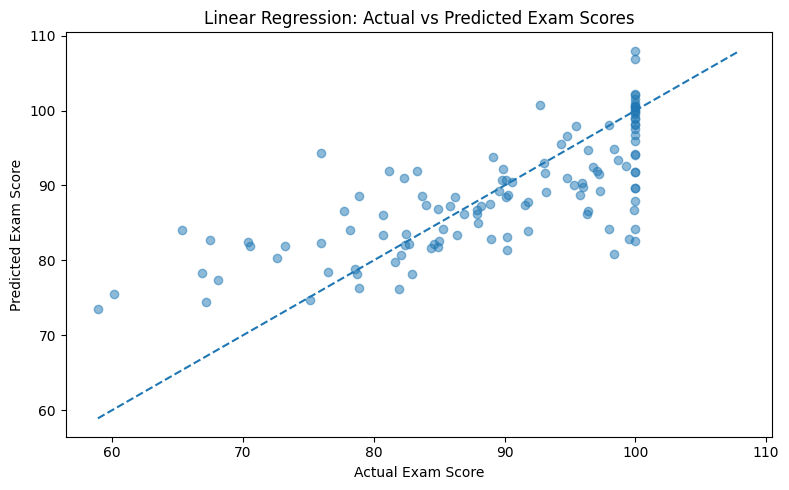

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(y_test, linear_pred, alpha=0.5)

min_score = min(y_test.min(), linear_pred.min())
max_score = max(y_test.max(), linear_pred.max())

ax.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

ax.set_title("Linear Regression: Actual vs Predicted Exam Scores")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")

fig.tight_layout()
fig.savefig("Figures/linear_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## 9. Inspect Linear Regression Coefficients

The coefficients show how each feature changes the predicted exam score while the other features are held constant.

We print the coefficients next to their feature names and identify the feature with the largest absolute effect.


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_,
})

coefficients["Absolute_Effect"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute_Effect", ascending=False)

print("Linear Regression coefficients:")
display(coefficients)

largest_effect = coefficients.iloc[0]
print(
    f"Largest absolute coefficient: {largest_effect['Feature']} "
    f"({largest_effect['Coefficient']:.4f})"
)


Linear Regression coefficients:


,Feature,Coefficient,Absolute_Effect
4,class_section_C,3.130369,3.130369
0,study_hours_per_week,2.032957,2.032957
3,class_section_B,0.124836,0.124836
2,attendance_pct,0.088670,0.088670
1,sleep_hours_per_night,-0.010655,0.010655


Largest absolute coefficient: class_section_C (3.1304)


In [15]:
print("## Coefficient Interpretation")
print(
    f"- The feature with the largest absolute coefficient is "
    f"{largest_effect['Feature']} ({largest_effect['Coefficient']:.4f})."
)
print(
    f"- Its positive coefficient indicates a positive effect on the predicted "
    f"exam score, while keeping other features constant."
)
print(
    f"- The coefficient for study_hours_per_week is "
    f"{coefficients.loc[coefficients['Feature'] == 'study_hours_per_week', 'Coefficient'].iloc[0]:.4f}, "
    f"indicating that study hours have a positive relationship with predicted exam score."
)
print(
    f"- The coefficient for sleep_hours_per_night is "
    f"{coefficients.loc[coefficients['Feature'] == 'sleep_hours_per_night', 'Coefficient'].iloc[0]:.4f}, "
    f"indicating a very small effect in this fitted model."
)
print(
    f"- Overall, the coefficient magnitudes suggest that "
    f"{largest_effect['Feature']} has the strongest fitted effect among the included features."
)

## Coefficient Interpretation
- The feature with the largest absolute coefficient is class_section_C (3.1304).
- Its positive coefficient indicates a positive effect on the predicted exam score, while keeping other features constant.
- The coefficient for study_hours_per_week is 2.0330, indicating that study hours have a positive relationship with predicted exam score.
- The coefficient for sleep_hours_per_night is -0.0107, indicating a very small effect in this fitted model.
- Overall, the coefficient magnitudes suggest that class_section_C has the strongest fitted effect among the included features.


## Intercept Analysis

The intercept is the constant term of the Linear Regression model. It represents the baseline value of the model when all input features are set to zero.

Calculating the intercept helps us understand the complete Linear Regression equation and how the model combines the intercept with the feature coefficients to make predictions.

The intercept is mainly a mathematical starting point and should not necessarily be interpreted as a realistic exam score, because a student with all features equal to zero may not represent a meaningful real-world case.

In [16]:
intercept = linear_model.intercept_

print(f"Linear Regression intercept: {intercept:.4f}")

Linear Regression intercept: 59.4341


## Intercept Interpretation

- The Linear Regression model has a positive intercept, which represents the constant term of the regression equation.
- The intercept serves as the model's baseline value before the effects of the input features are added.
- It should not be interpreted as an actual expected exam score because a student with all input features equal to zero is not a meaningful real-world case.
- The intercept, together with the feature coefficients, forms the complete Linear Regression model used to generate exam score predictions.

## 10. Classification Target — Distinction

Create a binary target:

- `1` if `exam_score >= 85`
- `0` otherwise

The fraction of students reaching 85 is important because it tells us how balanced the target is and helps us interpret accuracy.


In [17]:
students["distinction"] = (students["exam_score"] >= 85).astype(int)

distinction_fraction = students["distinction"].mean()
class_counts = students["distinction"].value_counts().sort_index()

print(f"Fraction reaching distinction (>= 85): {distinction_fraction:.4f}")
print(f"Percentage reaching distinction: {distinction_fraction * 100:.2f}%")
print("\nClass counts:")
print(class_counts)


Fraction reaching distinction (>= 85): 0.6533
Percentage reaching distinction: 65.33%

Class counts:
distinction
0    208
1    392
Name: count, dtype: int64


## Distinction Classification

The `distinction` variable converts the continuous exam score into a binary classification target.

Students with an exam score of 85 or above are assigned `1` (distinction), while students scoring below 85 are assigned `0`.

The results show that the majority of students reached the distinction threshold. The dataset contains both classes, with 392 students classified as distinction and 208 students classified as non-distinction.

This binary target can be used later to build a classification model that predicts whether a student will achieve distinction based on their study habits, sleep, attendance, and class section.

## 11. Classification Train/Test Split

For classification, use a **fresh stratified split**. `stratify=y_class` keeps approximately the same class balance in both training and test sets.

The features remain exactly the same model-ready matrix created earlier.


In [18]:
y_class = students["distinction"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class,
)

print("Training rows:", len(X_train_cls))
print("Test rows:", len(X_test_cls))
print(f"Training distinction rate: {y_train_cls.mean():.4f}")
print(f"Test distinction rate:     {y_test_cls.mean():.4f}")


Training rows: 480
Test rows: 120
Training distinction rate: 0.6542
Test distinction rate:     0.6500


In [19]:
print(
    f"The training set contains {len(X_train_cls)} students "
    f"({len(X_train_cls) / len(X) * 100:.0f}% of the data), "
    f"while the test set contains {len(X_test_cls)} students "
    f"({len(X_test_cls) / len(X) * 100:.0f}% of the data)."
)

print(
    f"The distinction rate is {y_train_cls.mean() * 100:.2f}% in training "
    f"and {y_test_cls.mean() * 100:.2f}% in testing, "
    f"showing that stratification maintained a similar class distribution."
)

The training set contains 480 students (80% of the data), while the test set contains 120 students (20% of the data).
The distinction rate is 65.42% in training and 65.00% in testing, showing that stratification maintained a similar class distribution.


## 12. Classification Baseline — Most Frequent Class

The classification baseline predicts the most frequent class for every observation.

We calculate:
- **Accuracy:** overall fraction correct.
- **Precision:** among predicted positives, how many are actually positive.
- **Recall:** among actual positives, how many are detected.
- **F1:** harmonic mean of precision and recall.


In [20]:
cls_baseline = DummyClassifier(strategy="most_frequent")
cls_baseline.fit(X_train_cls, y_train_cls)

baseline_cls_pred = cls_baseline.predict(X_test_cls)

baseline_accuracy = accuracy_score(y_test_cls, baseline_cls_pred)
baseline_precision = precision_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)

print(f"Baseline accuracy:  {baseline_accuracy:.4f}")
print(f"Baseline precision: {baseline_precision:.4f}")
print(f"Baseline recall:    {baseline_recall:.4f}")
print(f"Baseline F1:        {baseline_f1:.4f}")


Baseline accuracy:  0.6500
Baseline precision: 0.6500
Baseline recall:    1.0000
Baseline F1:        0.7879


## Classification Baseline Interpretation

The baseline classifier uses the `most_frequent` strategy, meaning it always predicts the most common class in the training data.

The model provides a simple reference point for evaluating more advanced classification models. Its performance reflects the class distribution rather than learning meaningful relationships between the input features and distinction status.

The baseline achieves reasonable accuracy because distinction is the majority class. However, its recall is perfect because it predicts every test student as a distinction student. This also means that it cannot identify students who do not reach the distinction threshold.

Therefore, this baseline provides a useful benchmark, but it is not a meaningful predictive model.

### Why Accuracy Alone Can Mislead

If one class is more common than the other, a model can obtain a respectable accuracy simply by predicting the majority class every time. In that situation, precision, recall, and F1 expose the fact that the baseline is not actually identifying the positive class.


## 13. Logistic Regression

Now train a real Logistic Regression model on the same classification features and compare all four metrics directly against the baseline.


In [21]:
logistic_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
)

logistic_model.fit(X_train_cls, y_train_cls)

logistic_pred = logistic_model.predict(X_test_cls)

logistic_accuracy = accuracy_score(y_test_cls, logistic_pred)
logistic_precision = precision_score(
    y_test_cls, logistic_pred, zero_division=0
)
logistic_recall = recall_score(
    y_test_cls, logistic_pred, zero_division=0
)
logistic_f1 = f1_score(
    y_test_cls, logistic_pred, zero_division=0
)

print(f"Logistic Regression accuracy:  {logistic_accuracy:.4f}")
print(f"Logistic Regression precision: {logistic_precision:.4f}")
print(f"Logistic Regression recall:    {logistic_recall:.4f}")
print(f"Logistic Regression F1:        {logistic_f1:.4f}")


Logistic Regression accuracy:  0.7667
Logistic Regression precision: 0.8125
Logistic Regression recall:    0.8333
Logistic Regression F1:        0.8228


## Logistic Regression Interpretation

Logistic Regression is trained to predict whether a student reaches the distinction threshold based on the available features.

The model performs better than the most-frequent baseline because it learns relationships between the input features and the binary distinction target.

The accuracy, precision, recall, and F1-score provide different views of classification performance. In particular, precision measures the correctness of distinction predictions, while recall measures how many actual distinction students are correctly identified.

Although recall is lower than the baseline, Logistic Regression provides a better overall balance between precision and recall and can also distinguish between distinction and non-distinction students.

In [22]:
classification_comparison = pd.DataFrame({
    "Model": ["Dummy Most-Frequent Baseline", "Logistic Regression"],
    "Accuracy": [baseline_accuracy, logistic_accuracy],
    "Precision": [baseline_precision, logistic_precision],
    "Recall": [baseline_recall, logistic_recall],
    "F1": [baseline_f1, logistic_f1],
})

classification_comparison


,Model,Accuracy,Precision,Recall,F1
0,Dummy Most-Frequent Baseline,0.650000,0.6500,1.000000,0.787879
1,Logistic Regression,0.766667,0.8125,0.833333,0.822785


## ConfusionMatrixDisplay

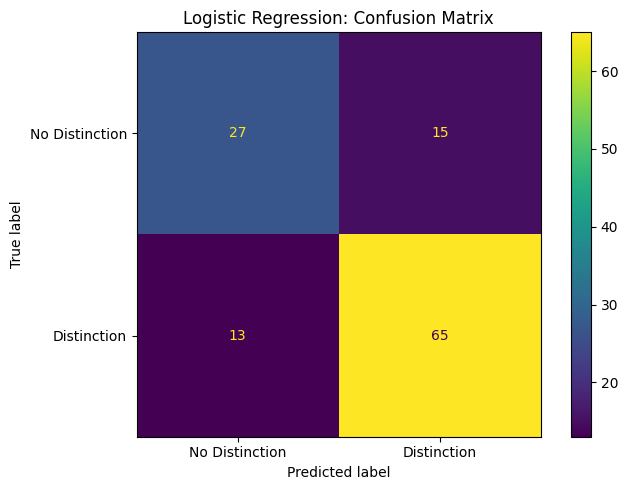

In [23]:


fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    logistic_pred,
    display_labels=["No Distinction", "Distinction"],
    ax=ax
)

ax.set_title("Logistic Regression: Confusion Matrix")

fig.tight_layout()
fig.savefig("Figures/logistic_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Interpretation

The confusion matrix shows that the Logistic Regression model correctly classified **27 students as No Distinction** and **65 students as Distinction**. It incorrectly classified **15 No Distinction students as Distinction** and **13 Distinction students as No Distinction**.

Overall, the model identified **65 out of 78 Distinction students** correctly, giving a recall of approximately **83.33%** for the Distinction class. It also correctly identified **27 out of 42 No Distinction students**, giving a recall of approximately **64.29%**.

The model performs better at identifying students who achieved Distinction than those who did not. This is consistent with the classification report, where the Distinction class has a higher F1-score (**0.82**) than the No Distinction class (**0.66**).

## 14. Direct Metric Improvements

Calculate exactly how much Logistic Regression changes each metric relative to the classification baseline.


In [24]:
classification_improvement = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
    ],
})

classification_improvement["Improvement"] = (
    classification_improvement["Logistic Regression"]
    - classification_improvement["Baseline"]
)

classification_improvement


,Metric,Baseline,Logistic Regression,Improvement
0,Accuracy,0.650000,0.766667,0.116667
1,Precision,0.650000,0.812500,0.162500
2,Recall,1.000000,0.833333,-0.166667
3,F1,0.787879,0.822785,0.034906


## Classification Model Improvement

The comparison shows that Logistic Regression improves overall classification performance compared with the most-frequent baseline.

Accuracy, precision, and F1-score increase, indicating that Logistic Regression makes more useful and balanced predictions.

Recall decreases compared with the baseline because the baseline predicts every student as the majority class, resulting in artificially perfect recall. Logistic Regression instead learns to distinguish between distinction and non-distinction students.

Overall, the improvement in accuracy, precision, and F1-score indicates that Logistic Regression is a more meaningful classifier than the baseline.

## Classifictaion Report

In [25]:
print("Classification report — Logistic Regression:")
print(classification_report(
    y_test_cls,
    logistic_pred,
    target_names=["No Distinction", "Distinction"],
    zero_division=0,
))


Classification report — Logistic Regression:
                precision    recall  f1-score   support

No Distinction       0.68      0.64      0.66        42
   Distinction       0.81      0.83      0.82        78

      accuracy                           0.77       120
     macro avg       0.74      0.74      0.74       120
  weighted avg       0.76      0.77      0.77       120



## Classification Report Interpretation

The classification report provides class-wise performance for the Logistic Regression model.

The model performs better on the Distinction class than on the No Distinction class. The Distinction class has stronger precision, recall, and F1-score, indicating that the model is more effective at identifying students who reach the distinction threshold.

The No Distinction class has lower recall, meaning that some students who do not reach the distinction threshold are incorrectly classified as distinction students.

The overall accuracy is around 77%, while the macro average provides an equal-weighted view of both classes and the weighted average accounts for their different class sizes.

Overall, the model provides reasonably balanced classification performance, with stronger results for predicting Distinction students.

## 15. Final Findings

The final conclusions below are generated from the actual metrics calculated above, rather than being hard-coded.


In [26]:
regression_winner = (
    linear_rmse < baseline_rmse and linear_r2 > baseline_r2
)

classification_winner = (
    logistic_f1 > baseline_f1
)

print("REGRESSION FINDING")
print(
    f"Linear Regression {'beats' if regression_winner else 'does not beat'} "
    f"the mean baseline: RMSE changes from {baseline_rmse:.4f} to "
    f"{linear_rmse:.4f}, while R² changes from {baseline_r2:.4f} to "
    f"{linear_r2:.4f}."
)

print("\nCOEFFICIENT FINDING")
print(
    f"The largest absolute Linear Regression coefficient is for "
    f"{largest_effect['Feature']}, with a coefficient of "
    f"{largest_effect['Coefficient']:.4f}."
)

print("\nCLASSIFICATION FINDING")
print(
    f"{distinction_fraction * 100:.2f}% of students meet the distinction "
    f"threshold (exam_score >= 85), so accuracy should be interpreted "
    f"together with precision, recall, and F1."
)

print("\nLOGISTIC REGRESSION FINDING")
print(
    f"Compared with the baseline, Logistic Regression changes accuracy by "
    f"{logistic_accuracy - baseline_accuracy:+.4f}, precision by "
    f"{logistic_precision - baseline_precision:+.4f}, recall by "
    f"{logistic_recall - baseline_recall:+.4f}, and F1 by "
    f"{logistic_f1 - baseline_f1:+.4f}."
)


REGRESSION FINDING
Linear Regression beats the mean baseline: RMSE changes from 10.2978 to 7.0584, while R² changes from -0.0096 to 0.5257.

COEFFICIENT FINDING
The largest absolute Linear Regression coefficient is for class_section_C, with a coefficient of 3.1304.

CLASSIFICATION FINDING
65.33% of students meet the distinction threshold (exam_score >= 85), so accuracy should be interpreted together with precision, recall, and F1.

LOGISTIC REGRESSION FINDING
Compared with the baseline, Logistic Regression changes accuracy by +0.1167, precision by +0.1625, recall by -0.1667, and F1 by +0.0349.


## 14. Reproducibility Check

This notebook uses:
- dataset seed = `21`
- regression split seed = `42`
- classification split seed = `42`
- Logistic Regression `random_state=21`

The full notebook is designed to run top-to-bottom after **Restart Kernel and Run All**, without manual reordering.


## Deliverable Summary

This notebook contains the complete baseline-to-first-model pipeline required for today:

1. One-hot encoded categorical features.
2. Fixed 80/20 regression train/test split.
3. Mean regression baseline with RMSE and R².
4. Linear Regression with RMSE and R².
5. Linear Regression coefficient analysis.
6. Binary distinction target at `exam_score >= 85`.
7. Fresh stratified classification split.
8. Most-frequent classification baseline with accuracy, precision, recall, and F1.
9. Logistic Regression with the same four metrics.
10. Direct baseline-vs-model metric comparisons.
11. Reproducible fixed-seed workflow.


# Week 06 · Day 4 — Review
## Stronger Models, Error Analysis, Calibration, and Final Model Defense

This section continues the Wednesday pipeline without changing the dataset, features, or train/test split. The goal is to compare stronger models fairly, diagnose errors, evaluate classifier calibration, and produce a defensible final evaluation.

## 16. Decision Tree Regression — Unconstrained

An unconstrained `DecisionTreeRegressor` is intentionally fitted first. We compare its training and test performance to make overfitting concrete using this run's actual numbers.

In [27]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.calibration import calibration_curve

# Unconstrained decision tree
tree_reg = DecisionTreeRegressor(random_state=RANDOM_SEED)
tree_reg.fit(X_train, y_train)

tree_train_pred = tree_reg.predict(X_train)
tree_test_pred = tree_reg.predict(X_test)

tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_pred))
tree_test_r2 = r2_score(y_test, tree_test_pred)

print(f"Unconstrained Tree training RMSE: {tree_train_rmse:.4f}")
print(f"Unconstrained Tree test RMSE:     {tree_test_rmse:.4f}")
print(f"Unconstrained Tree test R²:       {tree_test_r2:.4f}")
print(f"Train-to-test RMSE gap:           {tree_test_rmse - tree_train_rmse:.4f}")

Unconstrained Tree training RMSE: 0.0000
Unconstrained Tree test RMSE:     10.2120
Unconstrained Tree test R²:       0.0072
Train-to-test RMSE gap:           10.2120


### Interpretation — Unconstrained Decision Tree

The unconstrained Decision Tree achieved a training RMSE of **0.0000**, meaning the model fitted the training data almost perfectly and effectively memorized the training observations.

However, its test RMSE increased to **10.2120**, while the test R² was only **0.0072**. This means the model performed poorly on unseen data and explained only a very small portion of the variation in exam scores.

The **train-to-test RMSE gap of 10.2120** provides strong evidence of **overfitting**. The tree is too complex and has learned the specific patterns/noise of the training data instead of learning patterns that generalize well to new students.

Overall, this result demonstrates that an unconstrained Decision Tree can fit the training data extremely well but may have poor generalization performance.

## 17. Constrained Decision Tree Regression

Now the tree is constrained with `max_depth=3`. This reduces the model's ability to memorize individual training observations and tests whether generalization improves.

In [40]:
tree_depth3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_SEED)
tree_depth3.fit(X_train, y_train)

tree_depth3_train_pred = tree_depth3.predict(X_train)
tree_depth3_test_pred = tree_depth3.predict(X_test)

tree_depth3_train_rmse = np.sqrt(mean_squared_error(y_train, tree_depth3_train_pred))
tree_depth3_test_rmse = np.sqrt(mean_squared_error(y_test, tree_depth3_test_pred))
tree_depth3_test_r2 = r2_score(y_test, tree_depth3_test_pred)

print(f"Depth-3 Tree training RMSE: {tree_depth3_train_rmse:.4f}")
print(f"Depth-3 Tree test RMSE:     {tree_depth3_test_rmse:.4f}")
print(f"Depth-3 Tree test R²:       {tree_depth3_test_r2:.4f}")

Depth-3 Tree training RMSE: 7.0019
Depth-3 Tree test RMSE:     7.1031
Depth-3 Tree test R²:       0.5197


### Interpretation — Constrained Decision Tree (Max Depth = 3)

The depth-3 Decision Tree achieved a training RMSE of **7.0019** and a test RMSE of **7.1031**, showing that its performance on training and unseen test data is very similar.

The test R² of **0.5197** indicates that the model explains approximately **52% of the variation** in exam scores on the test set. Compared with the unconstrained tree, which had a test RMSE of **10.2120** and test R² of **0.0072**, the depth-3 tree generalizes much better.

The small train-to-test RMSE gap of approximately **0.1012** provides evidence that limiting the tree depth successfully reduced overfitting. Therefore, constraining the tree complexity improved its ability to generalize to unseen students.

## 18. Random Forest Regression

A random forest combines many decision trees and averages their predictions. It is trained on exactly the same regression split used by the baseline and linear regression.

In [29]:
forest_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_SEED
)
forest_reg.fit(X_train, y_train)

forest_reg_train_pred = forest_reg.predict(X_train)
forest_reg_test_pred = forest_reg.predict(X_test)

forest_reg_train_rmse = np.sqrt(mean_squared_error(y_train, forest_reg_train_pred))
forest_reg_test_rmse = np.sqrt(mean_squared_error(y_test, forest_reg_test_pred))
forest_reg_test_r2 = r2_score(y_test, forest_reg_test_pred)

regression_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_reg.feature_importances_,
}).sort_values("Importance", ascending=False)

print(f"Random Forest training RMSE: {forest_reg_train_rmse:.4f}")
print(f"Random Forest test RMSE:     {forest_reg_test_rmse:.4f}")
print(f"Random Forest test R²:       {forest_reg_test_r2:.4f}")
print("\nRandom Forest regression feature importances:")
display(regression_feature_importance)

print(
    f"\nMost important forest feature: "
    f"{regression_feature_importance.iloc[0]['Feature']} "
    f"({regression_feature_importance.iloc[0]['Importance']:.4f})"
)
print(
    f"Linear regression largest absolute coefficient: "
    f"{largest_effect['Feature']} "
    f"({largest_effect['Coefficient']:.4f})"
)

Random Forest training RMSE: 2.8716
Random Forest test RMSE:     7.3518
Random Forest test R²:       0.4854

Random Forest regression feature importances:


,Feature,Importance
0,study_hours_per_week,0.642413
2,attendance_pct,0.168028
1,sleep_hours_per_night,0.139100
4,class_section_C,0.033953
3,class_section_B,0.016505



Most important forest feature: study_hours_per_week (0.6424)
Linear regression largest absolute coefficient: class_section_C (3.1304)


### Interpretation — Random Forest Regression

The Random Forest Regressor achieved a training RMSE of **2.8716**, a test RMSE of **7.3518**, and a test R² of **0.4854**. The difference between training and test RMSE indicates some overfitting, but the model still provides reasonable predictions on unseen data.

The most important feature was **study_hours_per_week**, with a feature importance of **0.6424**, followed by **attendance_pct** with an importance of **0.1680**. This indicates that study hours contributed the most to the Random Forest's predictions.

Interestingly, the Random Forest identified **study_hours_per_week** as the most important feature, whereas Linear Regression had **class_section_C** as the feature with the largest absolute coefficient. This difference occurs because Random Forest feature importance and Linear Regression coefficients measure feature contribution differently.

Overall, the Random Forest performed reasonably well, but its test performance should be compared with the constrained Decision Tree and Linear Regression before selecting the final regression model.

## 19. Regression Model Comparison

All five required regression models are now compared on the same test set.

In [30]:
regression_comparison = pd.DataFrame({
    "Model": [
        "Dummy Mean Baseline",
        "Linear Regression",
        "Decision Tree (Unconstrained)",
        "Decision Tree (max_depth=3)",
        "Random Forest (200 trees)",
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_test_rmse,
        tree_depth3_test_rmse,
        forest_reg_test_rmse,
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        tree_test_r2,
        tree_depth3_test_r2,
        forest_reg_test_r2,
    ],
})

regression_comparison.sort_values("RMSE")

,Model,RMSE,R²
1,Linear Regression,7.058359,0.525702
3,Decision Tree (max_depth=3),7.103141,0.519664
4,Random Forest (200 trees),7.351789,0.485447
2,Decision Tree (Unconstrained),10.211954,0.007200
0,Dummy Mean Baseline,10.297789,-0.009560


### Interpretation — Regression Model Comparison

The regression models were compared using test RMSE and R². Lower RMSE and higher R² indicate better performance.

**Linear Regression** achieved the best overall performance, with the lowest test RMSE of **7.0584** and the highest test R² of **0.5257**. The **max_depth=3 Decision Tree** performed very similarly, with a test RMSE of **7.1031** and R² of **0.5197**.

The **Random Forest** achieved a test RMSE of **7.3518** and R² of **0.4854**, making it slightly weaker than both Linear Regression and the depth-3 Decision Tree. The unconstrained Decision Tree performed poorly, with a test RMSE of **10.2120** and R² of only **0.0072**, confirming the overfitting observed earlier.

The Dummy Mean Baseline had the weakest performance, with a test RMSE of **10.2978** and a negative R² of **-0.0096**. All three constrained/learned models performed better than this baseline.

Overall, **Linear Regression is the best regression model based on the test results**, because it achieved the lowest RMSE and highest R². Therefore, the more complex Random Forest should not be selected simply because it is more complex; the evaluation metrics provide stronger evidence for choosing Linear Regression.

## 20. Decision Tree Classification

The classification task uses the same distinction target and the same stratified train/test split from Wednesday.

In [42]:
tree_cls = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_cls.fit(X_train_cls, y_train_cls)

tree_cls_pred = tree_cls.predict(X_test_cls)

tree_cls_accuracy = accuracy_score(y_test_cls, tree_cls_pred)
tree_cls_precision = precision_score(y_test_cls, tree_cls_pred, zero_division=0)
tree_cls_recall = recall_score(y_test_cls, tree_cls_pred, zero_division=0)
tree_cls_f1 = f1_score(y_test_cls, tree_cls_pred, zero_division=0)

print(f"Decision Tree accuracy:  {tree_cls_accuracy:.4f}")
print(f"Decision Tree precision: {tree_cls_precision:.4f}")
print(f"Decision Tree recall:    {tree_cls_recall:.4f}")
print(f"Decision Tree F1:        {tree_cls_f1:.4f}")

Decision Tree accuracy:  0.7167
Decision Tree precision: 0.7973
Decision Tree recall:    0.7564
Decision Tree F1:        0.7763


### Interpretation — Decision Tree Classifier

The Decision Tree Classifier achieved an **accuracy of 0.7167**, meaning it correctly classified approximately **72%** of the test observations.

The model achieved a **precision of 0.7973**, indicating that when the model predicted the positive class, approximately **80%** of those predictions were correct.

The **recall of 0.7564** shows that the model successfully identified approximately **76%** of the actual positive cases.

The **F1-score of 0.7763** indicates a good balance between precision and recall. Overall, the Decision Tree provides reasonable classification performance and can now be compared with Logistic Regression and Random Forest using the same evaluation metrics.

## 21. Random Forest Classification

The random forest classifier is trained with 200 trees and the same classification split.

In [43]:
forest_cls = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED
)
forest_cls.fit(X_train_cls, y_train_cls)

forest_cls_pred = forest_cls.predict(X_test_cls)

forest_cls_accuracy = accuracy_score(y_test_cls, forest_cls_pred)
forest_cls_precision = precision_score(y_test_cls, forest_cls_pred, zero_division=0)
forest_cls_recall = recall_score(y_test_cls, forest_cls_pred, zero_division=0)
forest_cls_f1 = f1_score(y_test_cls, forest_cls_pred, zero_division=0)

classification_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_cls.feature_importances_,
}).sort_values("Importance", ascending=False)

print(f"Random Forest accuracy:  {forest_cls_accuracy:.4f}")
print(f"Random Forest precision: {forest_cls_precision:.4f}")
print(f"Random Forest recall:    {forest_cls_recall:.4f}")
print(f"Random Forest F1:        {forest_cls_f1:.4f}")
print("\nRandom Forest classification feature importances:")
display(classification_feature_importance)

Random Forest accuracy:  0.7417
Random Forest precision: 0.7831
Random Forest recall:    0.8333
Random Forest F1:        0.8075

Random Forest classification feature importances:


,Feature,Importance
0,study_hours_per_week,0.527676
2,attendance_pct,0.224336
1,sleep_hours_per_night,0.205742
4,class_section_C,0.022606
3,class_section_B,0.019639


### Interpretation — Random Forest Classifier

The Random Forest Classifier achieved an **accuracy of 0.7417**, **precision of 0.7831**, **recall of 0.8333**, and **F1-score of 0.8075** on the test set.

The **recall of 0.8333** indicates that the model correctly identified most of the actual positive cases. The **F1-score of 0.8075** also shows a good balance between precision and recall.

For feature importance, **study_hours_per_week** was the most important feature with an importance of **0.5277**, followed by **attendance_pct** with **0.2243** and **sleep_hours_per_night** with **0.2057**. The class-section features had relatively low importance.

Overall, the Random Forest Classifier performed well and will be compared with Logistic Regression and the Decision Tree using accuracy, precision, recall, and F1-score to select the best classification model.

## 22. Classification Model Comparison and Defense

In [33]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Dummy Most-Frequent Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (200 trees)",
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_cls_accuracy,
        forest_cls_accuracy,
    ],
    "Precision": [
        baseline_precision,
        logistic_precision,
        tree_cls_precision,
        forest_cls_precision,
    ],
    "Recall": [
        baseline_recall,
        logistic_recall,
        tree_cls_recall,
        forest_cls_recall,
    ],
    "F1": [
        baseline_f1,
        logistic_f1,
        tree_cls_f1,
        forest_cls_f1,
    ],
})

classification_comparison.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.766667,0.812500,0.833333,0.822785
3,Random Forest (200 trees),0.741667,0.783133,0.833333,0.807453
0,Dummy Most-Frequent Baseline,0.650000,0.650000,1.000000,0.787879
2,Decision Tree,0.716667,0.797297,0.756410,0.776316


### Interpretation — Classification Model Comparison

The classification models were compared using **accuracy, precision, recall, and F1-score**, where higher values indicate better performance.

**Logistic Regression** achieved the best overall performance, with the highest **accuracy of 0.7667** and the highest **F1-score of 0.8228**. It also achieved a **precision of 0.8125** and a **recall of 0.8333**.

The **Random Forest** performed second best, with an accuracy of **0.7417** and an F1-score of **0.8075**. Although it achieved the same recall of **0.8333** as Logistic Regression, its precision was lower at **0.7831**.

The **Dummy Most-Frequent Baseline** achieved a recall of **1.0000**, but this is misleading because it predicts the majority class for every observation. Its F1-score of **0.7879** and accuracy of **0.6500** are lower than Logistic Regression and Random Forest.

The **Decision Tree** had the lowest F1-score among the trained models at **0.7763**, with an accuracy of **0.7167**.

Overall, **Logistic Regression is the best classification model** based on the test results because it achieved the highest accuracy and F1-score while maintaining the same recall as Random Forest. Therefore, the more complex Random Forest should not be selected simply because it is more complex; the evaluation metrics provide stronger evidence for choosing Logistic Regression.

## 23. Regression Error Analysis — Five Worst Predictions

The selected regression model is Linear Regression. For every test row, calculate the residual as `actual − predicted`, sort by absolute residual, and inspect the five largest mistakes.

In [34]:
regression_errors = students.loc[X_test.index, [
    "student_id",
    "class_section",
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_pct",
    "exam_score",
]].copy()

regression_errors["predicted_exam_score"] = linear_pred
regression_errors["residual"] = (
    regression_errors["exam_score"] - regression_errors["predicted_exam_score"]
)
regression_errors["absolute_error"] = regression_errors["residual"].abs()

worst_regression_errors = regression_errors.sort_values(
    "absolute_error", ascending=False
).head(5)

worst_regression_errors

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score,predicted_exam_score,residual,absolute_error
575,576,A,8.9,8.5,75.3,65.3,84.113694,-18.813694,18.813694
515,516,B,13.9,10.0,74.3,76.0,94.298663,-18.298663,18.298663
70,71,A,6.8,7.6,87.1,98.4,80.900381,17.499619,17.499619
506,507,A,7.6,5.5,87.7,100.0,82.602325,17.397675,17.397675
257,258,C,7.0,6.3,69.3,99.5,82.872864,16.627136,16.627136


### Interpretation — Regression Error Analysis

The five largest absolute prediction errors were examined using the **Linear Regression** model. The largest error occurred for student **576**, where the actual exam score was **65.3** but the predicted score was **84.1137**, resulting in an absolute error of **18.8137**.

The second-largest error occurred for student **516**, with an actual score of **76.0** and a predicted score of **94.2987**, giving an absolute error of **18.2987**. For students **71, 507, and 258**, the model overestimated or underestimated the exam scores by approximately **16.63–17.50 points**.

A noticeable pattern is that several large errors occur for students with relatively **low attendance** or unusual combinations of study hours, sleep hours, and attendance. For example, students **576 and 516** have attendance values of **75.3% and 74.3%**, respectively, while their predicted scores are considerably higher than their actual scores.

However, there is **no single clear feature pattern** explaining all five errors. The large residuals suggest that some factors affecting exam scores are not fully captured by the available features.

Overall, these observations indicate that Linear Regression performs well on average, but it can produce substantial errors for certain students, particularly when their actual performance differs from the general linear relationship learned by the model.

## 24. Classification Error Analysis — Misclassified Rows

For the selected Logistic Regression classifier, inspect every test row where the predicted class differs from the actual class.

In [35]:
classification_errors = students.loc[X_test_cls.index, [
    "student_id",
    "class_section",
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_pct",
]].copy()

classification_errors["actual_distinction"] = y_test_cls.values
classification_errors["predicted_distinction"] = logistic_pred
classification_errors["predicted_probability"] = logistic_model.predict_proba(
    X_test_cls
)[:, 1]

misclassified = classification_errors[
    classification_errors["actual_distinction"] != classification_errors["predicted_distinction"]
].sort_values("predicted_probability")

misclassified

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,actual_distinction,predicted_distinction,predicted_probability
219,220,C,3.6,6.1,97.4,1,0,0.168219
569,570,A,7.2,6.6,76.4,1,0,0.262340
493,494,B,8.3,5.5,64.8,1,0,0.298975
151,152,B,7.2,5.5,88.4,1,0,0.315213
460,461,A,6.6,9.5,98.1,1,0,0.324910
507,508,B,8.3,5.8,78.5,1,0,0.387312
275,276,A,7.5,7.6,93.8,1,0,0.408874
416,417,B,7.5,7.3,96.9,1,0,0.410085
552,553,A,8.1,6.9,88.7,1,0,0.452810
512,513,A,8.3,7.7,86.7,1,0,0.466212


### Interpretation — Classification Error Analysis

The misclassified observations show that the **Logistic Regression model** made errors in both directions: some students who actually belonged to the positive class were predicted as negative, while some negative-class students were predicted as positive.

Several false negatives had relatively low study hours or attendance. For example, student **220** had only **3.6 study hours per week**, while student **570** had **7.2 study hours** and **76.4% attendance**. These cases were assigned low predicted probabilities despite having an actual positive class.

On the other hand, several false positives had relatively high study hours or attendance. For example, student **218** had **13.0 study hours** and **94.0% attendance**, but the actual class was negative while the model predicted positive with a probability of **0.9689**.

Overall, the errors suggest that **study hours and attendance strongly influence the model's predictions**, but they do not perfectly determine the classification outcome. Some students have feature combinations that make their actual class difficult to predict using the available variables.

The misclassified cases therefore show that the Logistic Regression model performs well overall, but there are still borderline and unusual observations where the learned relationships do not match the actual classification.

## 25. Calibration Curve — Logistic Regression

Accuracy answers **how often the final labels are correct**. Calibration asks a different question: when the model says it is 70% confident, do roughly 70% of those cases actually belong to the positive class?

We use `predict_proba` and `calibration_curve` to compare mean predicted probability with the observed fraction of positives.

In [36]:
logistic_probabilities = logistic_model.predict_proba(X_test_cls)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test_cls,
    logistic_probabilities,
    n_bins=10,
    strategy="uniform",
)

calibration_table = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Actual Fraction Positive": fraction_of_positives,
})

calibration_table["Absolute Calibration Gap"] = (
    calibration_table["Mean Predicted Probability"]
    - calibration_table["Actual Fraction Positive"]
).abs()

display(calibration_table)

,Mean Predicted Probability,Actual Fraction Positive,Absolute Calibration Gap
0,0.060911,0.000000,0.060911
1,0.135682,0.111111,0.024571
2,0.256433,0.333333,0.076900
3,0.355572,0.500000,0.144428
4,0.460768,0.583333,0.122566
5,0.550008,0.714286,0.164277
6,0.644625,0.533333,0.111291
7,0.758815,0.785714,0.026900
8,0.861716,0.882353,0.020637
9,0.963648,0.962963,0.000685


### Interpretation — Calibration Analysis

The calibration curve compares the **predicted probabilities** from Logistic Regression with the **actual fraction of positive cases** in each probability bin. A well-calibrated model should have predicted probabilities close to the actual fraction of positives.

The model shows **good calibration at the lower and higher probability ranges**. For example, the highest-probability bin has a mean predicted probability of **0.9636** and an actual positive fraction of **0.9630**, giving a very small calibration gap of **0.0007**. Similarly, the bins around **0.76–0.86** also have relatively small gaps.

The weakest calibration occurs around the **middle probability range**, particularly the bin with a mean predicted probability of **0.5500** and an actual positive fraction of **0.7143**, resulting in the largest calibration gap of **0.1643**. This indicates that the model **underestimates the probability of positive cases** in this region.

Overall, the Logistic Regression probabilities are **reasonably trustworthy at the extreme probability ranges**, but predictions around the middle probability range are less reliable. The largest calibration error occurs around a predicted probability of **0.55**, where the actual positive rate is substantially higher than predicted.

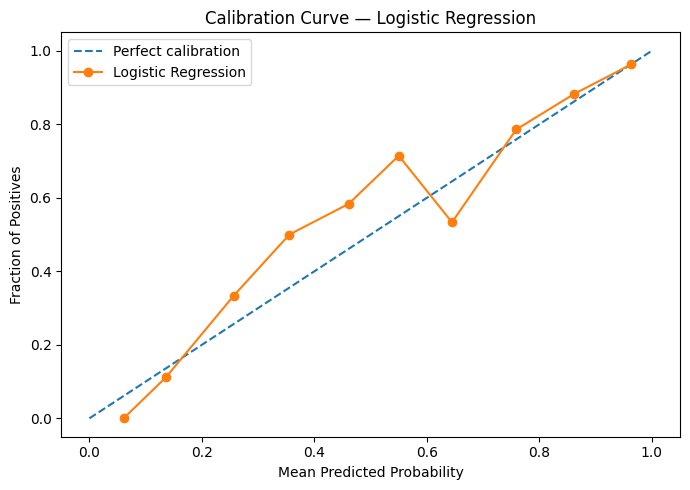

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)
ax.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Logistic Regression",
)

ax.set_title("Calibration Curve — Logistic Regression")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend()
fig.tight_layout()
fig.savefig("Figures/logistic_calibration_curve.png", bbox_inches="tight")
plt.show()

### Interpretation — Calibration Curve

The calibration curve compares the **predicted probabilities** from Logistic Regression with the **actual fraction of positive cases**. The dashed diagonal line represents **perfect calibration**, where predicted probabilities exactly match the observed positive rates.

The Logistic Regression curve is **reasonably close to the perfect calibration line**, especially at the lower and higher probability ranges. This indicates that the model's probability estimates are generally reliable.

The largest deviation occurs in the **middle probability range**, where the actual fraction of positives is noticeably higher than the predicted probability. This shows that the model **underestimates the likelihood of positive cases** for some students with moderate predicted probabilities.

At the highest probability range, the curve comes very close to the perfect calibration line, indicating **excellent calibration for high-confidence predictions**.

Overall, the model is **reasonably well calibrated**, but its probability estimates are less reliable around the middle probability range.

## 26. Final Evaluation Summary

This section records the final evidence from the complete Wednesday + Thursday pipeline.

In [38]:
best_regression_row = regression_comparison.sort_values("RMSE").iloc[0]
best_classification_row = classification_comparison.sort_values("F1", ascending=False).iloc[0]

print("FINAL MODEL SELECTION")
print(
    f"Regression: {best_regression_row['Model']} "
    f"(RMSE={best_regression_row['RMSE']:.4f}, R²={best_regression_row['R²']:.4f})"
)
print(
    f"Classification: {best_classification_row['Model']} "
    f"(Accuracy={best_classification_row['Accuracy']:.4f}, "
    f"Precision={best_classification_row['Precision']:.4f}, "
    f"Recall={best_classification_row['Recall']:.4f}, "
    f"F1={best_classification_row['F1']:.4f})"
)

print("\nKEY DEFENSE POINTS")
print(
    f"- Unconstrained tree train RMSE={tree_train_rmse:.4f}, "
    f"but test RMSE={tree_test_rmse:.4f}: clear overfitting."
)
print(
    f"- Depth-3 tree test RMSE={tree_depth3_test_rmse:.4f}, "
    f"which improves substantially over the unconstrained tree."
)
print(
    f"- Random forest test RMSE={forest_reg_test_rmse:.4f}, "
    f"so higher complexity does not beat the linear regression."
)
print(
    f"- Logistic regression F1={logistic_f1:.4f}, "
    f"versus forest F1={forest_cls_f1:.4f}; therefore the forest is not the best classifier here."
)

FINAL MODEL SELECTION
Regression: Linear Regression (RMSE=7.0584, R²=0.5257)
Classification: Logistic Regression (Accuracy=0.7667, Precision=0.8125, Recall=0.8333, F1=0.8228)

KEY DEFENSE POINTS
- Unconstrained tree train RMSE=0.0000, but test RMSE=10.2120: clear overfitting.
- Depth-3 tree test RMSE=7.1031, which improves substantially over the unconstrained tree.
- Random forest test RMSE=7.3518, so higher complexity does not beat the linear regression.
- Logistic regression F1=0.8228, versus forest F1=0.8075; therefore the forest is not the best classifier here.


## 27. Reproducibility Checklist

- Dataset regenerated with seed `21`.
- Regression train/test split uses `random_state=42`.
- Classification train/test split uses `random_state=42` with `stratify=y_class`.
- Decision trees and random forests use `random_state=21` through `RANDOM_SEED`.
- Random forest models use exactly `n_estimators=200`.
- All models use the same engineered feature matrix.
- Metrics are computed on held-out test data.
- The notebook is designed to run from top to bottom without manual cell reordering.
- The calibration figure is saved under `Figures/logistic_calibration_curve.png`.

# Standalone Evaluation Report

See the accompanying `Week6_Day4_Evaluation_Report.md` file for the reader-facing evaluation report covering the task, baselines, model comparison, final model choices, error analysis, and calibration finding.